Implementing DC-DC Cuk converter outlined in the paper: 
"Data-driven model reduction by moment matching for linear and nonlinear systems" 

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


The given input function is: 
\begin{equation}
u(t) = \max \left( 0.15, \frac{1}{2} \left(\omega_1 \omega_2 + \omega_1 ^ 3 + \frac{1}{2}\right) \right)
\end{equation}

\begin{equation}
\omega_1 = 0.15 \sin(75t)
\end{equation}

\begin{equation}
\omega_2 = 0.15 ( 75 \cos(75t) )
\end{equation}

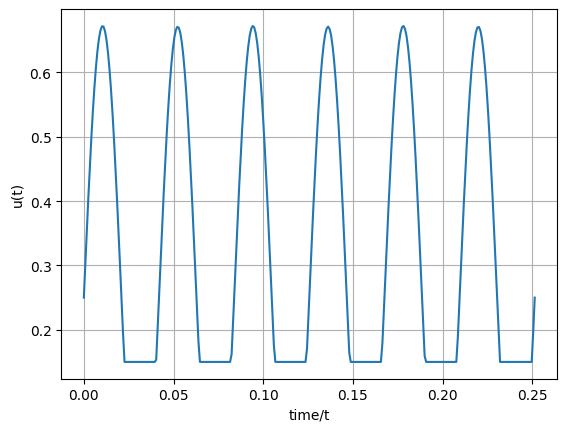

In [200]:
def u(t):
    omega1 = 0.15* np.sin(75*t)
    omega2 = 0.15* 75 * np.cos(75*t)

    func = (0.5 * ( omega1 * omega2 + omega1 ** 3 + 0.5))

    return np.where( func < 0.15, 0.15, func)

T = np.linspace(0, (6*np.pi) / 75, 300)
U = u(T)

plt.plot(T, U)
plt.grid(True)
plt.ylabel("u(t)")
plt.xlabel("time/t")
plt.show()





The averaged model of the Cuk converter is: 
yadayada


80000


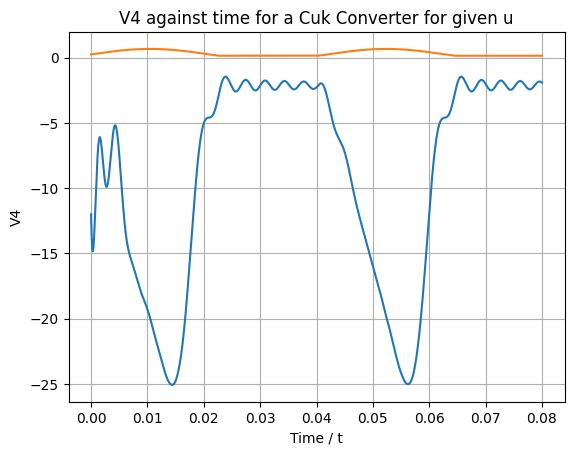

In [201]:
L1 = 10.0e-3
C2 = 22.0e-6
L3 = 10.0e-3
C4 = 22.9e-6
G = 0.0447
E = 12.0

def Cukconverter(t, x):
    x1, x2, x3, x4 = x
    u_val = u(t)

    dx1 = ( -(1.0 - u_val)*x2 + E) / L1
    dx2 = ( (1.0 - u_val ) * x1 + u_val*x3) / C2
    dx3 = (-u_val * x2 - x4) / L3
    dx4 = ( x3 - G*x4) / C4

    return [dx1, dx2, dx3, dx4]

x0 = [0.5, 10.0, -1, -12.0]
t_span = (0, 0.08)
t_eval = np.linspace(t_span[0], t_span[1], 80000)
# time interval is 0.08 / 8000 = 1.0e-5 seconds

# Solve
sol = solve_ivp(Cukconverter, t_span, x0, t_eval=t_eval)

T_list = sol.t
v4_list = sol.y[3]  # x4
print(len(v4_list))

plt.plot(T_list, v4_list)
plt.plot(T_list, u(T_list))
plt.grid(True)
plt.xlabel("Time / t")
plt.ylabel("V4")
plt.title("V4 against time for a Cuk Converter for given u")
plt.show()




REDUCED ORDER MODEL

Implementing Algorithm 2

In [202]:
# Let k be a sufficiently large integer. Select eta > 0
# sufficiently small. Select w geq v
# 1. Construct Uks and Gammaks matrices


Step 1. Constructing $ \widetilde{U_k} $ and $ \widetilde{\Upsilon_k}$ matrices

To construct $ \widetilde{U_k} $ we have to choose a set of basis functions. We can represent this set as a vector:
\begin{equation}
\Omega = 
\begin{bmatrix}
\phi(\omega(t)) & \phi_2 (\omega(t)) & \cdots & \phi_N(\omega(t))
\end{bmatrix}
\end{equation}
Then, the matrix $ \widetilde{U_k} $ is: 
\begin{equation}
\widetilde{U_k} = 
\begin{bmatrix}
\phi_1(\omega(t_{k-w+1})) & \phi_2 (\omega(t_{k-w+1})) & \cdots & \phi_N(\omega(t_{k-w+1})) \\
\cdots \\
\phi_1(\omega(t_{k})) & \phi_2 (\omega(t_{k})) & \cdots & \phi_N(\omega(t_{k}))
\end{bmatrix}
\end{equation}

In [ ]:
# For the specific case given in the paper
def omega(t):
    return 0.15* np.sin(75*t), 0.15* 75 * np.cos(75*t)


# Set of basis functions acting on omega calculated at t
# 5th order polynomials, in terms of the components of omega
def bigOmega(t, omega):
    o1, o2 = omega(t)

    # Define the basis terms more cleanly
    phi = [(i, j) for i in range(6) for j in range(5) if i + j > 0 and i <= 5 and j <= 5]

    Om = np.array([1] + [o1**i * o2**j for i, j in phi])
    return Om

# we choose k to be 800
k = 3000 # final time_index
w = 1750
Tk = np.array( [ j * 1.0e-5 for j in range(k-w+1, k+1)] )

def Utilde(Omega, w, k, Tk):
    def func(t):
        return Omega(t, omega)
    
    matrix = np.array( [ func(Tk[i]) for i in range(w) ] ) #forms a matrix where the rows is Omega computed across Tk
    return matrix

Umatrix = Utilde( bigOmega, w, k, Tk )




30


Construcing $ \widetilde{\Upsilon_k}$ matrix:

In [204]:
def Upsilon(y, Tk, w, k):
    matrix = np.array( [ y[i] for i in range(k-w+1, k+1)])
    return matrix

y_list = Upsilon( v4_list, Tk, w, k)

    

"STEP 2: 
IF $ \text{rank}( \widetilde{U_k}^T \widetilde{U_k}) = N $, compute $\widetilde{ \Gamma_k }$, else increase w. 
If $k-w < 0$ then restart algorithm selecting a larger initial k. "

In [207]:
from numpy.linalg import matrix_rank



k0 = 3000 # final time_index
w0 = 1750
# Tk = np.array( [ j * 1.0e-5 for j in range(k0-w0+1, k+1)] )

def rank_checker( A ): 

    # Checks the rank the matrix product (A_transpose, A)

    A_transpose = np.transpose(A)
    ATA = np.matmul( A_transpose, A )
    return matrix_rank(ATA)

def step2_kw_adjustment( omega, w0, k0, y ): # vector of basis functions, starting w, starting k, output list of values
    N = 30
    for k in range( k0, len(y) ):
        for w in range(1, k):
            if k > w: 
                Tk = np.array( [ j * 1.0e-5 for j in range( k-w+1, k+1 )] )

                Umatrix = Utilde( omega, w, k, Tk )

                rank = rank_checker( Umatrix )
                if rank == N:
                    return Umatrix
                
Umatrix_adjusted = step2_kw_adjustment( bigOmega, w0, k0, v4_list )




    
    
    


        

KeyboardInterrupt: 